# Exploratory Data Analysis - Life Expectancy (WHO) Dataset
This notebook is fully focused on EDA (Univariate + Bivariate Analysis) on the cleaned,
outlier-treated dataset. Insights from each plot are written as comments in the code
so they are easy to pull out for a presentation.

## 1. Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

## 2. Load the Cleaned Dataset

In [2]:
# load the already cleaned + outlier-treated dataset
df = pd.read_csv("cleaned_life_expectancyyy.csv")
print("Shape:", df.shape)
df.head()

Shape: (2938, 12)


,Status,Adult Mortality,BMI,HIV/AIDS,Diphtheria,thinness 1-19 years,Polio,GDP,Alcohol,Income composition of resources,Schooling,Life expectancy
0,0,263.0,19.1,0.1,65.0,15.35,49.5,584.259210,0.01,0.479,10.1,65.0
1,0,271.0,18.6,0.1,62.0,15.35,58.0,612.696514,0.01,0.476,10.0,59.9
2,0,268.0,18.1,0.1,64.0,15.35,62.0,631.744976,0.01,0.470,9.9,59.9
3,0,272.0,17.6,0.1,67.0,15.35,67.0,669.959000,0.01,0.463,9.8,59.5
4,0,275.0,17.2,0.1,68.0,15.35,68.0,63.537231,0.01,0.454,9.5,59.2


In [3]:
# basic statistics of every column
df.describe()

,Status,Adult Mortality,BMI,HIV/AIDS,Diphtheria,thinness 1-19 years,Polio,GDP,Alcohol,Income composition of resources,Schooling,Life expectancy
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000
mean,0.174268,161.953370,38.381178,0.536215,85.301906,4.687474,85.356535,3443.019953,4.546310,0.634903,12.060824,69.234717
std,0.379405,115.488489,19.935375,0.693393,15.790731,3.933064,15.809647,3777.901722,3.920116,0.191836,3.101263,9.509115
min,0.000000,1.000000,1.000000,0.100000,49.500000,0.100000,49.500000,1.681350,0.010000,0.102625,4.600000,36.300000
25%,0.000000,74.000000,19.400000,0.100000,78.000000,1.600000,78.000000,580.486996,1.092500,0.504250,10.300000,63.200000
50%,0.000000,144.000000,43.500000,0.100000,93.000000,3.300000,93.000000,1766.947595,3.755000,0.677000,12.300000,72.100000
75%,0.000000,227.000000,56.100000,0.800000,97.000000,7.100000,97.000000,4779.405190,7.390000,0.772000,14.100000,75.600000
max,1.000000,456.500000,87.300000,1.850000,99.000000,15.350000,99.000000,11077.782482,16.836250,0.948000,19.800000,89.000000


## 3. Univariate Analysis
Looking at one column at a time to understand its own distribution.

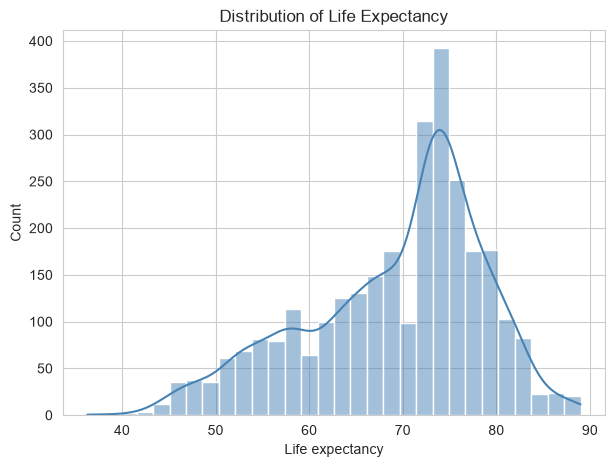

In [ ]:
# distribution of Life Expectancy
plt.figure(figsize=(7,5))
sns.histplot(df["Life expectancy"],bins=30,kde=True,color="steelblue")
plt.title("Distribution of Life Expectancy")
plt.show()
# Insight: Life expectancy is left-skewed - most countries are clustered between 65-80 years,
# with a smaller tail of countries pulled down toward 40-55 years.

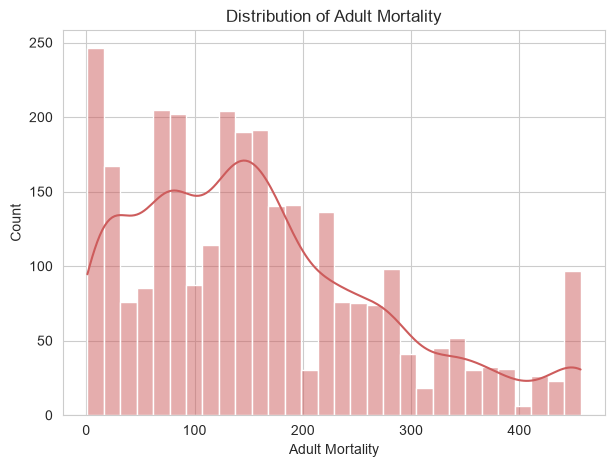

In [ ]:
# distribution of Adult Mortality
plt.figure(figsize=(7,5))
sns.histplot(df["Adult Mortality"],bins=30,kde=True,color="indianred")
plt.title("Distribution of Adult Mortality")
plt.show()
# Insight: Adult Mortality is right-skewed - most countries have low mortality,
# but a noticeable group has very high adult mortality rates.

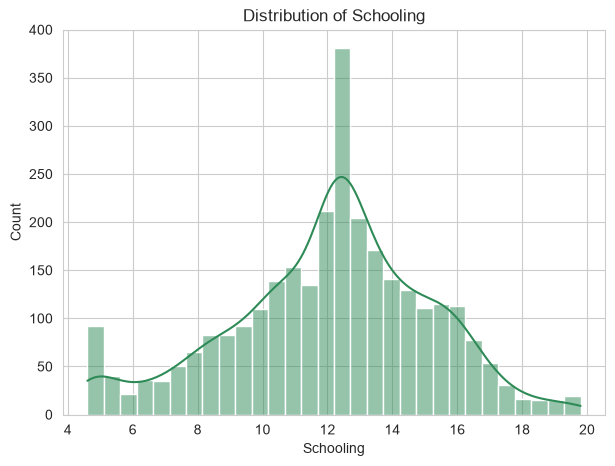

In [ ]:
# distribution of Schooling
plt.figure(figsize=(7,5))
sns.histplot(df["Schooling"],bins=30,kde=True, olor="seagreen")
plt.title("Distribution of Schooling")
plt.show()
# Insight: Schooling is fairly close to a normal distribution, centered around 11-13 years,
# meaning most countries offer a similar average number of years of education.

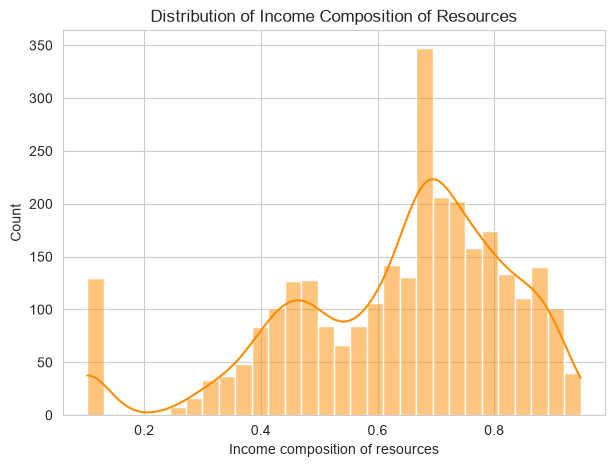

In [ ]:
# distribution of Income Composition of Resources
plt.figure(figsize=(7,5))
sns.histplot(df["Income composition of resources"],bins=30,kde=True,color="darkorange")
plt.title("Distribution of Income Composition of Resources")
plt.show()
# Insight: This column is left-skewed with a spike near 0, suggesting a group of countries
# with very poor income/resource utilization compared to the rest.

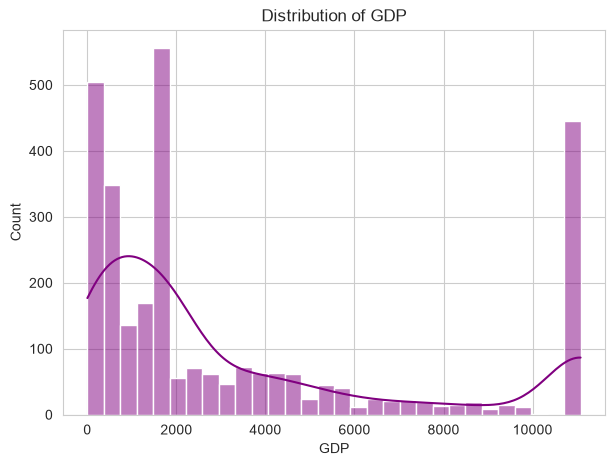

In [ ]:
# distribution of GDP
plt.figure(figsize=(7,5))
sns.histplot(df["GDP"],bins=30,kde=True,color="purple")
plt.title("Distribution of GDP")
plt.show()
# Insight: GDP is right-skewed - most countries have relatively low GDP values,
# while a smaller number of wealthier countries pull the distribution to the right.

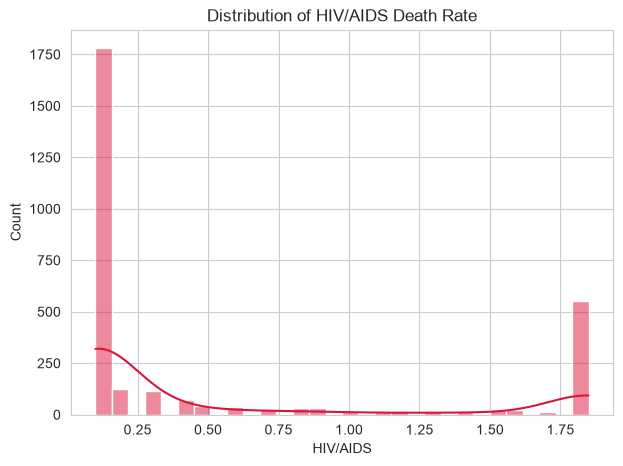

In [ ]:
# distribution of HIV/AIDS
plt.figure(figsize=(7,5))
sns.histplot(df["HIV/AIDS"],bins=30,kde=True,color="crimson")
plt.title("Distribution of HIV/AIDS Death Rate")
plt.show()
# Insight: Most countries have a very low HIV/AIDS death rate, but a small number of
# countries have a much higher rate, making this one of the most skewed columns.

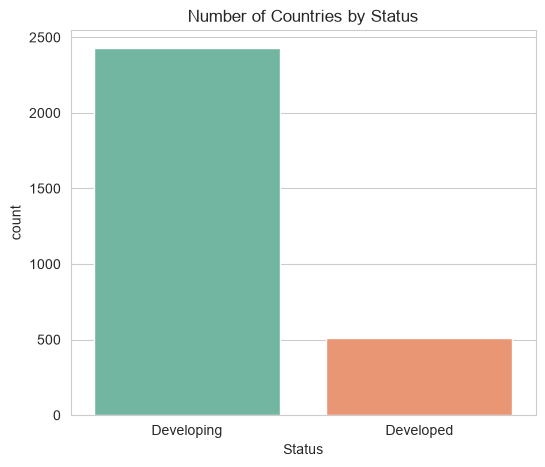

In [ ]:
# count of countries by Status (0 = Developing, 1 = Developed)
plt.figure(figsize=(6,5))
sns.countplot(x="Status",hue="Status",data=df,palette="Set2",legend=False)
plt.xticks([0,1],["Developing","Developed"])
plt.title("Number of Countries by Status")
plt.show()
# Insight: The dataset is imbalanced - there are far more "Developing" country records
# than "Developed" ones, which is why class_weight="balanced" is useful during modeling.

In [11]:
# skewness of every numeric column
df.skew(numeric_only=True).sort_values(ascending=False)
# Insight: Diphtheria and Polio are the most negatively skewed (most countries have high
# immunization coverage), while HIV/AIDS and GDP are the most positively skewed.

Status                             1.718238
HIV/AIDS                           1.209341
GDP                                1.156212
thinness  1-19 years               1.089204
Adult Mortality                    0.773346
Alcohol                            0.646383
BMI                               -0.229157
Schooling                         -0.320623
Life expectancy                   -0.642391
Income composition of resources   -0.904402
Polio                             -1.237938
Diphtheria                        -1.257041
dtype: float64

## 4. Bivariate Analysis
Looking at how two columns relate to each other.

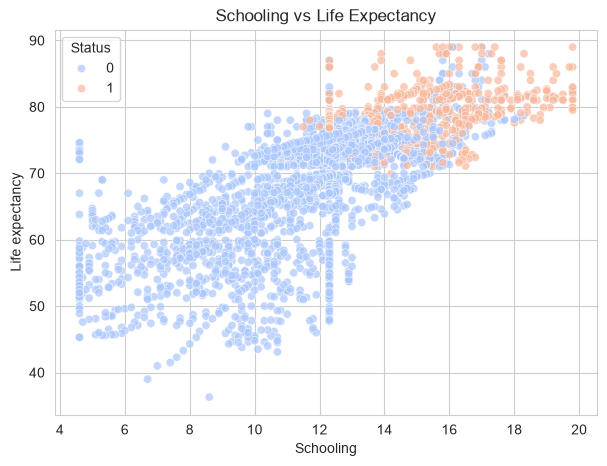

In [ ]:
# Schooling vs Life Expectancy
plt.figure(figsize=(7,5))
sns.scatterplot(x="Schooling",y="Lifeexpectancy",hue="Status",data=df,palette="coolwarm",alpha=0.7)
plt.title("Schooling vs Life Expectancy")
plt.show()
# Insight: A clear positive relationship - more years of schooling strongly line up with
# higher life expectancy, and Developed countries cluster in the high-schooling region.

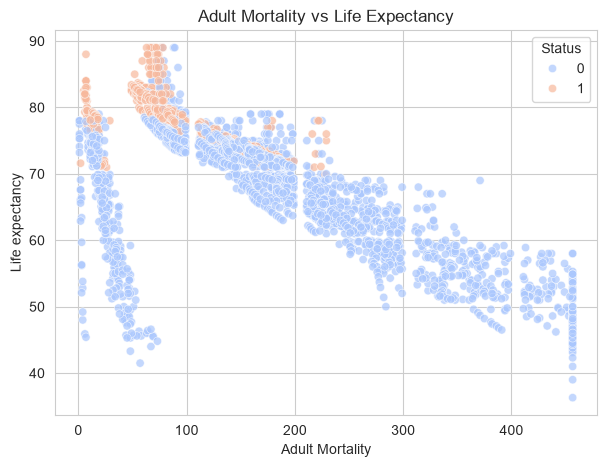

In [13]:
# Adult Mortality vs Life Expectancy
plt.figure(figsize=(7,5))
sns.scatterplot(x="Adult Mortality", y="Life expectancy", hue="Status", data=df, palette="coolwarm", alpha=0.7)
plt.title("Adult Mortality vs Life Expectancy")
plt.show()
# Insight: A strong negative relationship - as adult mortality rises, life expectancy
# drops sharply, making this one of the strongest predictors in the dataset.

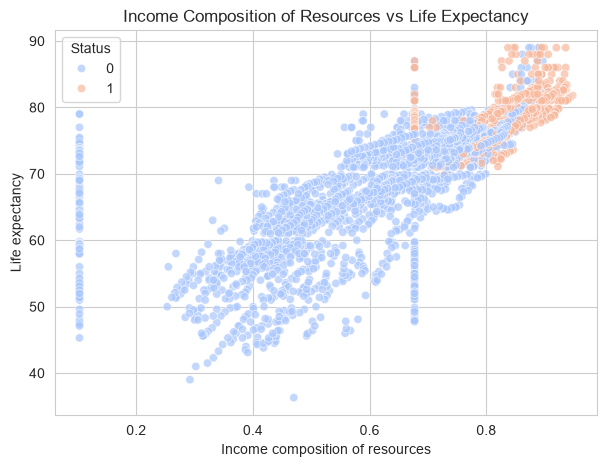

In [14]:
# Income Composition of Resources vs Life Expectancy
plt.figure(figsize=(7,5))
sns.scatterplot(x="Income composition of resources", y="Life expectancy", hue="Status", data=df, palette="coolwarm", alpha=0.7)
plt.title("Income Composition of Resources vs Life Expectancy")
plt.show()
# Insight: Higher income composition of resources goes hand in hand with higher life
# expectancy, and almost all Developed countries sit above 0.7 on this scale.

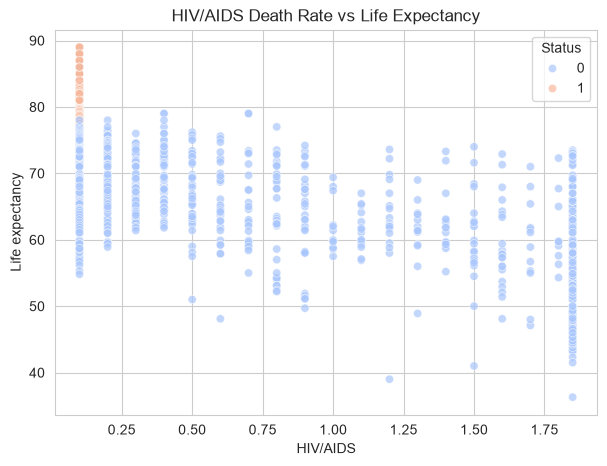

In [15]:
# HIV/AIDS vs Life Expectancy
plt.figure(figsize=(7,5))
sns.scatterplot(x="HIV/AIDS", y="Life expectancy", hue="Status", data=df, palette="coolwarm", alpha=0.7)
plt.title("HIV/AIDS Death Rate vs Life Expectancy")
plt.show()
# Insight: Countries with a higher HIV/AIDS death rate show a sharp drop in life
# expectancy, even though most countries are clustered at a low HIV/AIDS rate.

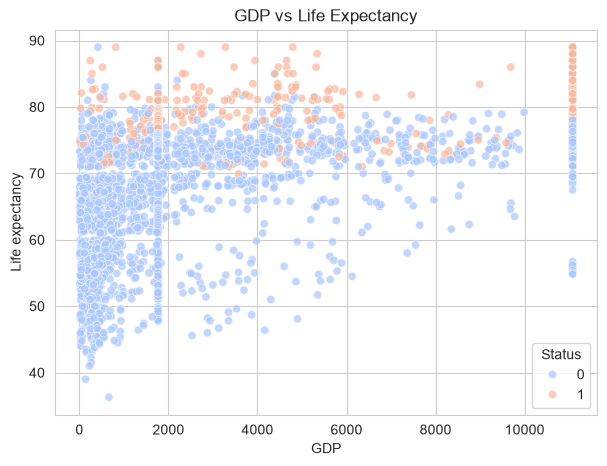

In [16]:
# GDP vs Life Expectancy
plt.figure(figsize=(7,5))
sns.scatterplot(x="GDP", y="Life expectancy", hue="Status", data=df, palette="coolwarm", alpha=0.7)
plt.title("GDP vs Life Expectancy")
plt.show()
# Insight: Life expectancy rises with GDP but flattens out after a point - beyond a
# certain GDP level, more wealth does not add much more life expectancy.

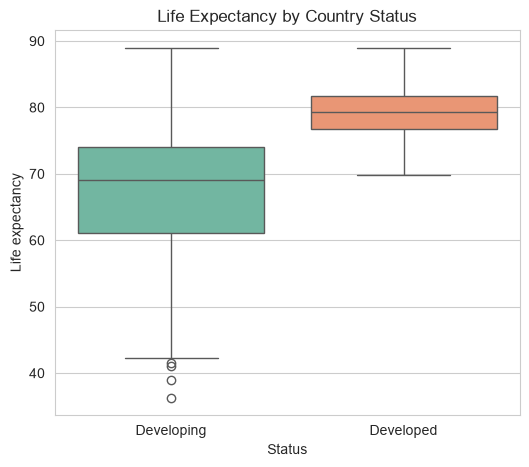

In [17]:
# Life Expectancy by Country Status
plt.figure(figsize=(6,5))
sns.boxplot(x="Status", y="Life expectancy", hue="Status", data=df, palette="Set2", legend=False)
plt.xticks([0,1], ["Developing","Developed"])
plt.title("Life Expectancy by Country Status")
plt.show()
# Insight: Developed countries have a noticeably higher median life expectancy and a
# tighter spread, while Developing countries show much wider variation.

In [18]:
# average life expectancy by status
df.groupby("Status")["Life expectancy"].mean()
# Insight: Developed countries average about 79 years of life expectancy, compared to
# about 67 years for Developing countries - a gap of roughly 12 years.

Status
0    67.132028
1    79.197852
Name: Life expectancy, dtype: float64

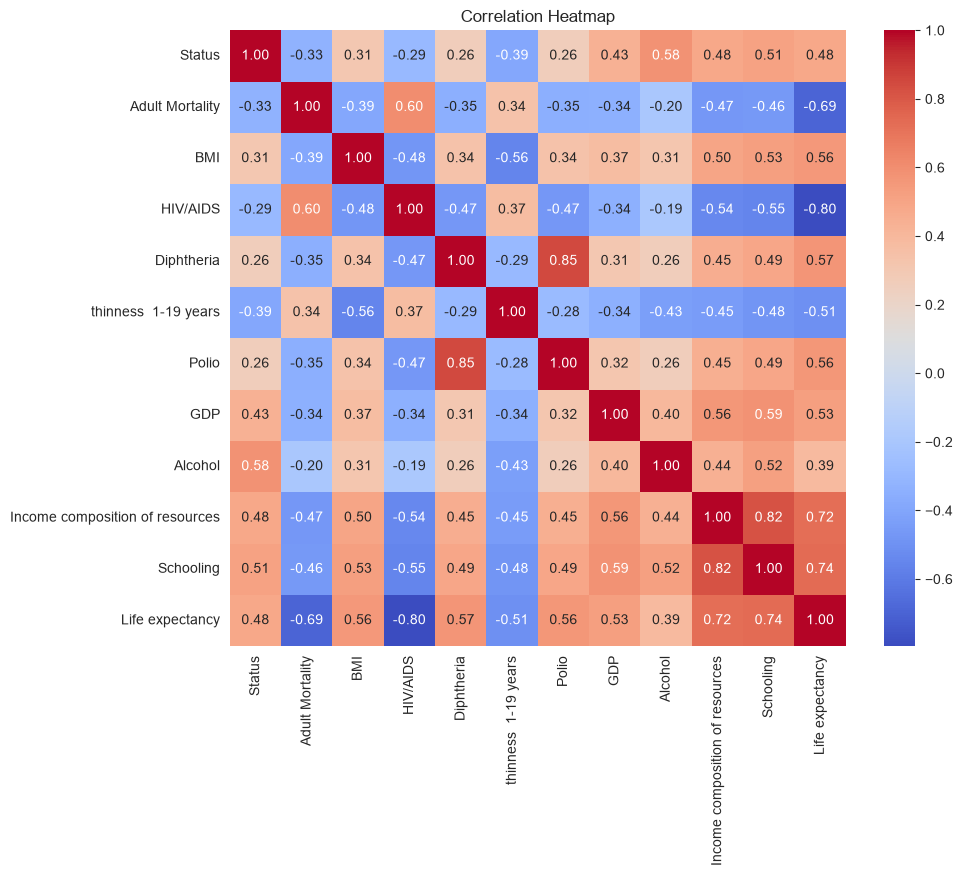

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()
# Insight: HIV/AIDS, Schooling, and Income Composition of Resources have the strongest
# correlation with Life Expectancy, while Alcohol has the weakest.

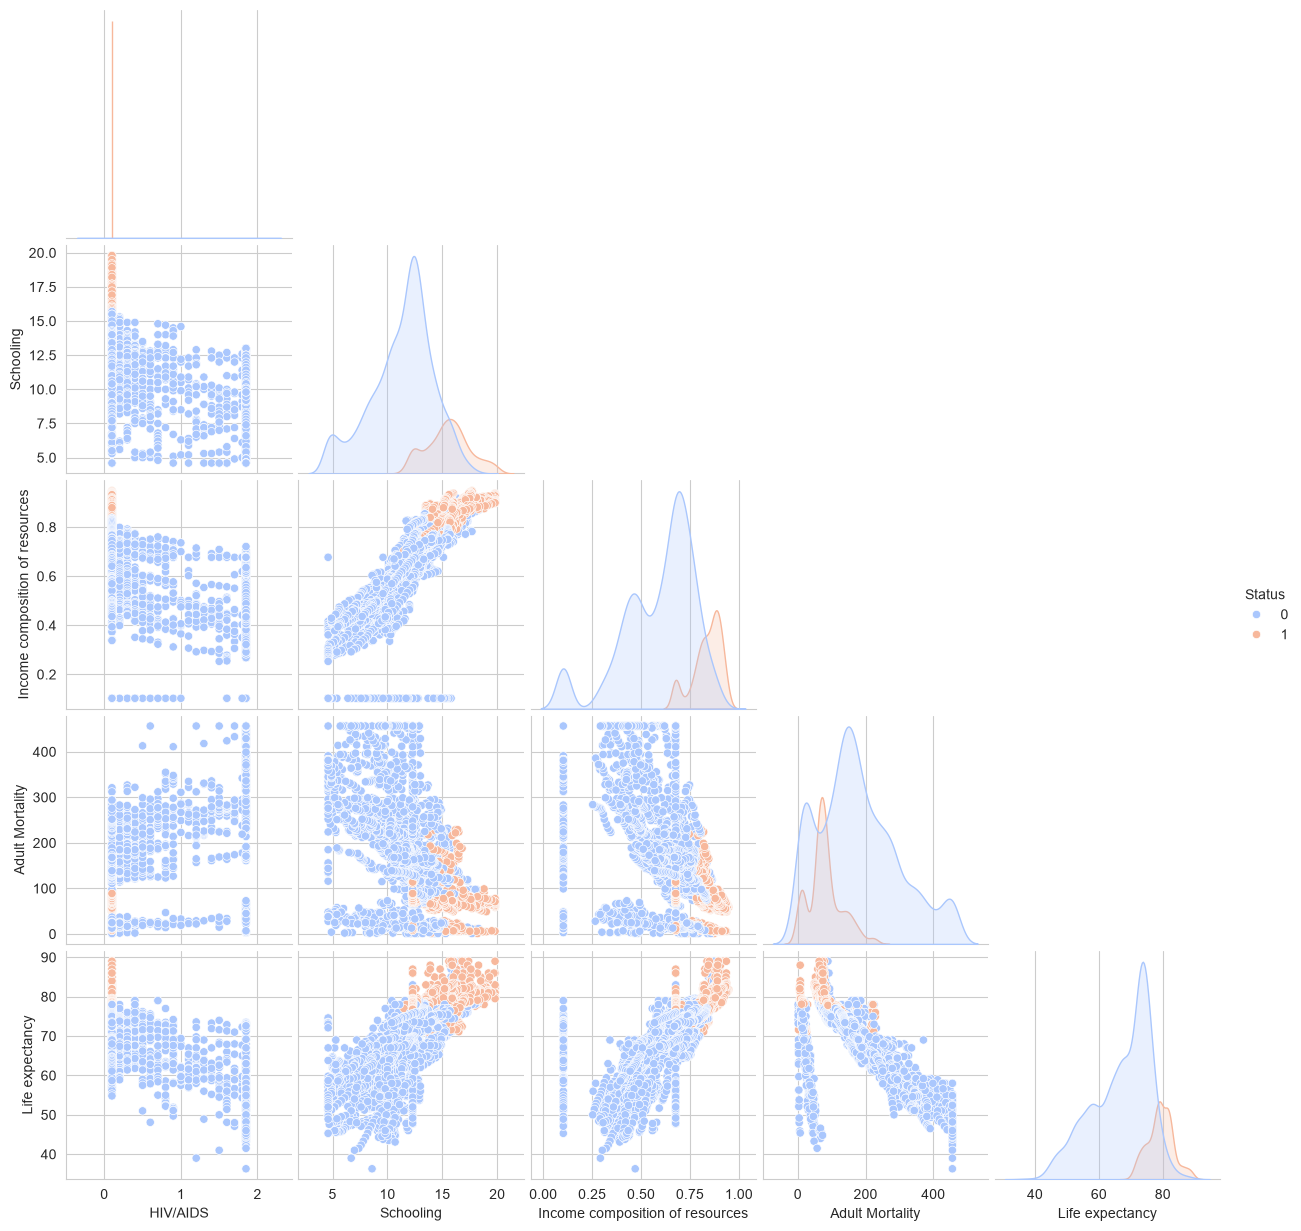

In [ ]:
# pairplot of the top correlated features, colored by Status
top_features = ["HIV/AIDS", "Schooling", "Income composition of resources", "Adult Mortality"]
sns.pairplot(df[top_features + ["Life expectancy", "Status"]], hue="Status", palette="coolwarm", corner=True)
plt.show()
# Insight: Developed countries (orange) consistently cluster in the high-schooling,
# high-income-composition, low-mortality corner of every plot - the same pattern